<a href="https://colab.research.google.com/github/gauravnevarekar/Integrated-Platform-for-Crowdsourced-Ocean-Hazard-Reporting-and-Social-Media-Analytic/blob/main/ML_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip sketch2face.zip

unzip:  cannot find or open sketch2face.zip, sketch2face.zip.zip or sketch2face.zip.ZIP.


In [ ]:
!git init
!git add .
!git commit -m "Initial commit - Pix2Pix Sketch to Face GAN"
!git remote add origin https://github.com/gauravnevarekar/sketch2face.git
!git push -u origin main

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@0ffcdce4388c.(none)')
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/gauravnevarekar/sketch2face.git

In [ ]:
!git clone https://github.com/gauravnevarekar/sketch2face.git
%cd sketch2face

Cloning into 'sketch2face'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'sketch2face'
/content


In [ ]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [ ]:
!python data/scripts/download_dataset.py

python3: can't open file '/content/data/scripts/download_dataset.py': [Errno 2] No such file or directory


In [ ]:
!pwd
!ls

/content
sample_data


In [ ]:
# If you see 'sketch2face' folder in the list above, run this:
%cd /content/sketch2face

# Then verify the file exists
!ls data/scripts/

[Errno 2] No such file or directory: '/content/sketch2face'
/content
ls: cannot access 'data/scripts/': No such file or directory


In [ ]:
!python data/scripts/download_dataset.py

python3: can't open file '/content/data/scripts/download_dataset.py': [Errno 2] No such file or directory


In [ ]:
# Go back to root
%cd /content

# Remove any broken folder
!rm -rf sketch2face

# Clone again
!git clone https://github.com/gauravnevarekar/sketch2face.git

# Go inside it
%cd sketch2face

# Confirm files are there
!ls




/content
Cloning into 'sketch2face'...
fatal: could not read Username for 'https://github.com': No such device or address
[Errno 2] No such file or directory: 'sketch2face'
/content
sample_data


In [ ]:
!mkdir -p /content/sketch2face/data/scripts
!mkdir -p /content/sketch2face/models
!mkdir -p /content/sketch2face/train
!mkdir -p /content/sketch2face/inference
!mkdir -p /content/sketch2face/app
!mkdir -p /content/sketch2face/checkpoints
%cd /content/sketch2face

/content/sketch2face


In [ ]:
!python data/scripts/download_dataset.py

python3: can't open file '/content/sketch2face/data/scripts/download_dataset.py': [Errno 2] No such file or directory


In [ ]:
!find /content -name "*.py" 2>/dev/null
!echo "---"
!ls /content/
!echo "---"
!ls /content/sketch2face/ 2>/dev/null || echo "sketch2face folder does NOT exist"

---
sample_data  sketch2face
---
app  checkpoints  data	inference  models  train


In [ ]:
%%writefile /content/sketch2face/data/scripts/download_dataset.py
import os
import cv2
import gdown
import zipfile
import numpy as np
from pathlib import Path
from tqdm import tqdm
from PIL import Image

DATA_DIR     = Path("data/celeba_hq_paired")
IMG_SIZE     = 256
NUM_SAMPLES  = 5000

def download_dataset():
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR / "celeba_hq.zip"
    print("Downloading CelebA-HQ dataset (~2 GB)...")
    gdown.download(
        "https://drive.google.com/uc?id=1badu11NqxGf6qM3PTTooiDkr3HzQHK0",
        str(zip_path), quiet=False
    )
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    zip_path.unlink()
    print("Download complete.")

def generate_edge_map(img):
    gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges   = cv2.Canny(blurred, threshold1=30, threshold2=100)
    sketch  = cv2.bitwise_not(edges)
    return cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)

def create_paired_dataset(raw_dir, out_dir):
    (out_dir / "train").mkdir(parents=True, exist_ok=True)
    (out_dir / "val").mkdir(parents=True, exist_ok=True)
    image_paths = sorted(raw_dir.glob("*.jpg"))[:NUM_SAMPLES]
    split_idx   = int(len(image_paths) * 0.9)
    print(f"Creating {len(image_paths)} paired images...")
    for i, img_path in enumerate(tqdm(image_paths)):
        photo  = np.array(Image.open(img_path).resize((IMG_SIZE, IMG_SIZE)).convert("RGB"))
        sketch = generate_edge_map(photo)
        paired = np.concatenate([sketch, photo], axis=1)
        split  = "train" if i < split_idx else "val"
        Image.fromarray(paired).save(out_dir / split / f"{i:05d}.jpg", quality=95)
    print("Dataset ready!")

if __name__ == "__main__":
    raw_dir = DATA_DIR / "celeba_hq_256"
    if not raw_dir.exists():
        download_dataset()
    create_paired_dataset(raw_dir, DATA_DIR)

Writing /content/sketch2face/data/scripts/download_dataset.py


In [ ]:
%%writefile /content/sketch2face/models/generator.py
import torch
import torch.nn as nn

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
                  nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True)]
        if dropout:
            layers.append(nn.Dropout(0.5))
        self.block = nn.Sequential(*layers)
    def forward(self, x, skip):
        return torch.cat([self.block(x), skip], dim=1)

class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, features=64):
        super().__init__()
        self.e1 = ConvBlock(in_channels, features, normalize=False)
        self.e2 = ConvBlock(features,    features*2)
        self.e3 = ConvBlock(features*2,  features*4)
        self.e4 = ConvBlock(features*4,  features*8)
        self.e5 = ConvBlock(features*8,  features*8)
        self.e6 = ConvBlock(features*8,  features*8)
        self.e7 = ConvBlock(features*8,  features*8)
        self.bottleneck = nn.Sequential(
            nn.Conv2d(features*8, features*8, 4, stride=2, padding=1), nn.ReLU(inplace=True))
        self.d1 = UpBlock(features*8,  features*8, dropout=True)
        self.d2 = UpBlock(features*16, features*8, dropout=True)
        self.d3 = UpBlock(features*16, features*8, dropout=True)
        self.d4 = UpBlock(features*16, features*8)
        self.d5 = UpBlock(features*16, features*4)
        self.d6 = UpBlock(features*8,  features*2)
        self.d7 = UpBlock(features*4,  features)
        self.final = nn.Sequential(
            nn.ConvTranspose2d(features*2, out_channels, 4, stride=2, padding=1), nn.Tanh())
    def forward(self, x):
        e1=self.e1(x); e2=self.e2(e1); e3=self.e3(e2); e4=self.e4(e3)
        e5=self.e5(e4); e6=self.e6(e5); e7=self.e7(e6)
        bn=self.bottleneck(e7)
        d1=self.d1(bn,e7); d2=self.d2(d1,e6); d3=self.d3(d2,e5); d4=self.d4(d3,e4)
        d5=self.d5(d4,e3); d6=self.d6(d5,e2); d7=self.d7(d6,e1)
        return self.final(d7)

Writing /content/sketch2face/models/generator.py


In [ ]:
%%writefile /content/sketch2face/models/discriminator.py
import torch
import torch.nn as nn

class PatchBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, normalize=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride=stride, padding=1, bias=False)]
        if normalize:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)

class Discriminator(nn.Module):
    def __init__(self, in_channels=3, features=64):
        super().__init__()
        self.model = nn.Sequential(
            PatchBlock(in_channels*2, features,   normalize=False),
            PatchBlock(features,      features*2),
            PatchBlock(features*2,    features*4),
            PatchBlock(features*4,    features*8, stride=1),
            nn.Conv2d(features*8, 1, 4, stride=1, padding=1))
    def forward(self, sketch, photo):
        return self.model(torch.cat([sketch, photo], dim=1))

Writing /content/sketch2face/models/discriminator.py


In [ ]:
%%writefile /content/sketch2face/models/losses.py
import torch
import torch.nn as nn

class GANLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.BCEWithLogitsLoss()
    def __call__(self, predictions, is_real):
        targets = torch.ones_like(predictions) if is_real else torch.zeros_like(predictions)
        return self.loss_fn(predictions, targets)

class Pix2PixLoss:
    def __init__(self, lambda_l1=100.0):
        self.lambda_l1 = lambda_l1
        self.gan_loss  = GANLoss()
        self.l1_loss   = nn.L1Loss()
    def discriminator_loss(self, D, sketch, real_photo, fake_photo):
        loss_real = self.gan_loss(D(sketch, real_photo), is_real=True)
        loss_fake = self.gan_loss(D(sketch, fake_photo.detach()), is_real=False)
        return (loss_real + loss_fake) * 0.5
    def generator_loss(self, D, sketch, real_photo, fake_photo):
        loss_adv = self.gan_loss(D(sketch, fake_photo), is_real=True)
        loss_l1  = self.l1_loss(fake_photo, real_photo) * self.lambda_l1
        return loss_adv + loss_l1, loss_adv, loss_l1

Writing /content/sketch2face/models/losses.py


In [ ]:
%cd /content/sketch2face
!python train/train.py \
  --data_dir data/celeba_hq_paired \
  --epochs 100 \
  --batch_size 4 \
  --save_dir checkpoints/

/content/sketch2face
python3: can't open file '/content/sketch2face/train/train.py': [Errno 2] No such file or directory


# New Section

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

images = sorted(glob.glob("training_progress/*.jpg"))
if images:
    img = mpimg.imread(images[-1])
    plt.figure(figsize=(15,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Sketch | Generated Face | Real Face")
    plt.show()
    print(f"Showing: {images[-1]}")
else:
    print("No preview yet — wait for epoch 5")

No preview yet — wait for epoch 5


In [ ]:
# Check what epoch you're on
!ls training_progress/ 2>/dev/null || echo "No images saved yet"

# Also check if training is still going
!ls checkpoints/ 2>/dev/null || echo "No checkpoints yet"

No images saved yet


In [ ]:
# Run this to see exactly what's happening
!ls /content/sketch2face/
!echo "---"
!ls /content/sketch2face/train/ 2>/dev/null || echo "train folder MISSING"
!echo "---"
!ls /content/sketch2face/data/celeba_hq_paired/ 2>/dev/null || echo "dataset MISSING"

app  checkpoints  data	inference  models  train
---
---
dataset MISSING


In [ ]:
%%writefile /content/sketch2face/train/train.py
import os, sys, argparse
from pathlib import Path
import torch
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import numpy as np
from tqdm import tqdm

sys.path.append('/content/sketch2face')
from models.generator     import Generator
from models.discriminator import Discriminator
from models.losses        import Pix2PixLoss

class SketchFaceDataset(Dataset):
    def __init__(self, data_dir, split="train"):
        self.paths = sorted(Path(data_dir, split).glob("*.jpg"))
        self.transform = transforms.Compose([
            transforms.Resize((256,256)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        paired = Image.open(self.paths[idx]).convert("RGB")
        w, h   = paired.size
        sketch = paired.crop((0,0,w//2,h))
        photo  = paired.crop((w//2,0,w,h))
        if torch.rand(1) > 0.5:
            sketch = transforms.functional.hflip(sketch)
            photo  = transforms.functional.hflip(photo)
        return self.transform(sketch), self.transform(photo)

def train(args):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using: {device}")
    G = Generator().to(device)
    D = Discriminator().to(device)
    def init_weights(m):
        if isinstance(m,(torch.nn.Conv2d,torch.nn.ConvTranspose2d)):
            torch.nn.init.normal_(m.weight,0.0,0.02)
    G.apply(init_weights); D.apply(init_weights)
    opt_G = optim.Adam(G.parameters(), lr=args.lr, betas=(0.5,0.999))
    opt_D = optim.Adam(D.parameters(), lr=args.lr, betas=(0.5,0.999))
    train_ds = SketchFaceDataset(args.data_dir,"train")
    val_ds   = SketchFaceDataset(args.data_dir,"val")
    train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,  num_workers=2)
    val_dl   = DataLoader(val_ds,   batch_size=4,               shuffle=False, num_workers=2)
    print(f"Dataset: {len(train_ds)} train, {len(val_ds)} val")
    loss_fn  = Pix2PixLoss(lambda_l1=100)
    save_dir = Path(args.save_dir)
    img_dir  = Path("training_progress")
    save_dir.mkdir(parents=True, exist_ok=True)
    img_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, args.epochs+1):
        G.train(); D.train()
        d_losses, g_losses = [], []
        for sketch, real_photo in tqdm(train_dl, desc=f"Epoch {epoch}/{args.epochs}"):
            sketch     = sketch.to(device)
            real_photo = real_photo.to(device)
            fake_photo = G(sketch)
            opt_D.zero_grad()
            d_loss = loss_fn.discriminator_loss(D,sketch,real_photo,fake_photo)
            d_loss.backward(); opt_D.step()
            fake_photo = G(sketch)
            opt_G.zero_grad()
            g_loss,g_adv,g_l1 = loss_fn.generator_loss(D,sketch,real_photo,fake_photo)
            g_loss.backward(); opt_G.step()
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
        print(f"  D: {sum(d_losses)/len(d_losses):.4f} | G: {sum(g_losses)/len(g_losses):.4f}")

        if epoch % 5 == 0 or epoch == 1:
            G.eval()
            with torch.no_grad():
                val_sketch, val_real = next(iter(val_dl))
                val_fake = G(val_sketch.to(device))
            grid = torch.cat([
                val_sketch[:4]*0.5+0.5,
                val_fake[:4].cpu()*0.5+0.5,
                val_real[:4]*0.5+0.5], dim=0)
            save_image(grid, img_dir/f"epoch_{epoch:04d}.jpg", nrow=4)
            print(f"  Preview saved → training_progress/epoch_{epoch:04d}.jpg")

        if epoch % 10 == 0:
            torch.save(G.state_dict(), save_dir/f"generator_epoch{epoch:04d}.pth")
            print(f"  Checkpoint saved")

    torch.save(G.state_dict(), save_dir/"generator_final.pth")
    print("Training complete!")

if __name__ == "__main__":
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir",   default="data/celeba_hq_paired")
    parser.add_argument("--epochs",     default=100, type=int)
    parser.add_argument("--batch_size", default=4,   type=int)
    parser.add_argument("--lr",         default=0.0002, type=float)
    parser.add_argument("--save_dir",   default="checkpoints/")
    train(parser.parse_args())

Writing /content/sketch2face/train/train.py


In [ ]:
%cd /content/sketch2face
!python train/train.py \
  --data_dir data/celeba_hq_paired \
  --epochs 100 \
  --batch_size 4 \
  --save_dir checkpoints/


/content/sketch2face
Using: cuda
Traceback (most recent call last):
  File "/content/sketch2face/train/train.py", line 101, in <module>
    train(parser.parse_args())
  File "/content/sketch2face/train/train.py", line 48, in train
    train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,  num_workers=2)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 394, in __init__
    sampler = RandomSampler(dataset, generator=generator)  # type: ignore[arg-type]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/sampler.py", line 149, in __init__
    raise ValueError(
ValueError: num_samples should be a positive integer value, but got num_samples=0


In [ ]:
%cd /content/sketch2face
import sys
sys.path.append('/content/sketch2face')
!python train/train.py --data_dir data/celeba_hq_paired --epochs 100 --batch_size 4 --save_dir checkpoints/


/content/sketch2face
Using: cuda
Traceback (most recent call last):
  File "/content/sketch2face/train/train.py", line 101, in <module>
    train(parser.parse_args())
  File "/content/sketch2face/train/train.py", line 48, in train
    train_dl = DataLoader(train_ds, batch_size=args.batch_size, shuffle=True,  num_workers=2)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 394, in __init__
    sampler = RandomSampler(dataset, generator=generator)  # type: ignore[arg-type]
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/sampler.py", line 149, in __init__
    raise ValueError(
ValueError: num_samples should be a positive integer value, but got num_samples=0


In [ ]:
# Install kaggle dataset downloader
!pip install -q kagglehub

import kagglehub
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
from tqdm import tqdm

# Download CelebA dataset (reliable mirror)
print("Downloading dataset...")
path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"Downloaded to: {path}")

# Setup folders
IMG_SIZE  = 256
NUM       = 3000
train_dir = Path("/content/sketch2face/data/celeba_hq_paired/train")
val_dir   = Path("/content/sketch2face/data/celeba_hq_paired/val")
train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)

# Find all images
all_images = sorted(Path(path).rglob("*.jpg"))[:NUM]
print(f"Found {len(all_images)} images")

# Generate sketch+photo pairs
def make_sketch(img):
    gray    = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5,5), 0)
    edges   = cv2.Canny(blurred, 30, 100)
    sketch  = cv2.bitwise_not(edges)
    return cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)

split = int(len(all_images) * 0.9)
print("Creating paired images...")
for i, img_path in enumerate(tqdm(all_images)):
    try:
        photo  = np.array(Image.open(img_path).resize((IMG_SIZE, IMG_SIZE)).convert("RGB"))
        sketch = make_sketch(photo)
        paired = np.concatenate([sketch, photo], axis=1)
        folder = train_dir if i < split else val_dir
        Image.fromarray(paired).save(folder / f"{i:05d}.jpg", quality=95)
    except:
        continue

train_count = len(list(train_dir.glob("*.jpg")))
val_count   = len(list(val_dir.glob("*.jpg")))
print(f"Done! {train_count} train, {val_count} val images")

Using Colab cache for faster access to the 'celeba-dataset' dataset.
Downloaded to: /kaggle/input/celeba-dataset
Found 3000 images
Creating paired images...


100%|██████████| 3000/3000 [00:22<00:00, 130.78it/s]

Done! 2700 train, 300 val images


In [ ]:
%cd /content/sketch2face
!python train/train.py \
  --data_dir data/celeba_hq_paired \
  --epochs 10 \
  --batch_size 4 \
  --save_dir checkpoints/

/content/sketch2face
Using: cuda
Dataset: 2700 train, 300 val
Epoch 1/10: 100% 675/675 [02:14<00:00,  5.03it/s]
  D: 0.2672 | G: 50.8771
  Preview saved → training_progress/epoch_0001.jpg
Epoch 2/10: 100% 675/675 [02:18<00:00,  4.88it/s]
  D: 0.3433 | G: 48.3452
Epoch 3/10: 100% 675/675 [02:19<00:00,  4.85it/s]
  D: 0.3633 | G: 46.7010
Epoch 4/10: 100% 675/675 [02:18<00:00,  4.86it/s]
  D: 0.3671 | G: 45.2848
Epoch 5/10: 100% 675/675 [02:18<00:00,  4.88it/s]
  D: 0.3633 | G: 44.4719
  Preview saved → training_progress/epoch_0005.jpg
Epoch 6/10: 100% 675/675 [02:18<00:00,  4.86it/s]
  D: 0.3602 | G: 43.1435
Epoch 7/10: 100% 675/675 [02:19<00:00,  4.86it/s]
  D: 0.3653 | G: 42.0160
Epoch 8/10: 100% 675/675 [02:18<00:00,  4.86it/s]
  D: 0.3771 | G: 41.0219
Epoch 9/10: 100% 675/675 [02:19<00:00,  4.85it/s]
  D: 0.3811 | G: 39.8583
Epoch 10/10: 100% 675/675 [02:18<00:00,  4.86it/s]
  D: 0.3913 | G: 38.2020
  Preview saved → training_progress/epoch_0010.jpg
  Checkpoint saved
Training comple

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.makedirs('/content/sketch2face/checkpoints', exist_ok=True)
!cp /content/drive/MyDrive/sketch2face_checkpoints/generator_final.pth /content/sketch2face/checkpoints/

Found 3 preview images


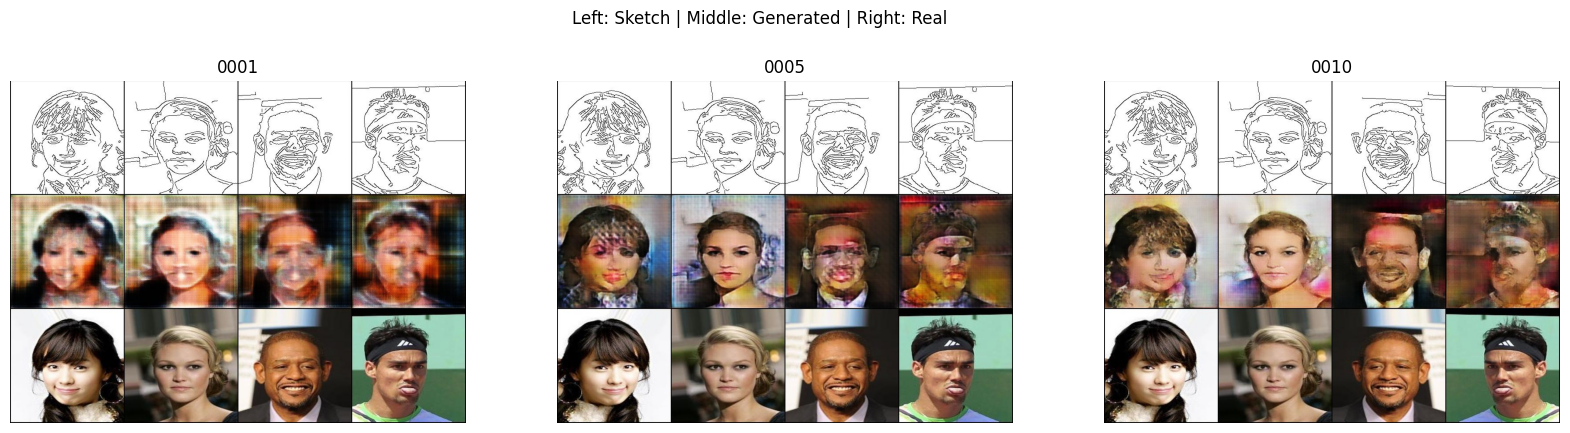

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

images = sorted(glob.glob("/content/sketch2face/training_progress/*.jpg"))
print(f"Found {len(images)} preview images")

# Show all previews so you can see improvement
fig, axes = plt.subplots(1, len(images), figsize=(20, 5))
for i, img_path in enumerate(images):
    axes[i].imshow(mpimg.imread(img_path))
    axes[i].set_title(img_path.split("_")[-1].replace(".jpg",""))
    axes[i].axis("off")
plt.suptitle("Left: Sketch | Middle: Generated | Right: Real")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/sketch2face/checkpoints",
    "/content/drive/MyDrive/sketch2face_checkpoints",
    dirs_exist_ok=True
)
print("✅ Checkpoints saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Checkpoints saved to Google Drive!


In [ ]:
%cd /content/sketch2face
!python train/train.py \
  --data_dir data/celeba_hq_paired \
  --epochs 40   \
  --batch_size 4 \
  --save_dir checkpoints/

/content/sketch2face
Using: cuda
Dataset: 2700 train, 300 val
Epoch 1/40:   5% 35/675 [00:07<02:17,  4.64it/s]
Traceback (most recent call last):
  File "/content/sketch2face/train/train.py", line 101, in <module>
    train(parser.parse_args())
  File "/content/sketch2face/train/train.py", line 71, in train
    d_losses.append(d_loss.item())
                    ^^^^^^^^^^^^^
KeyboardInterrupt
^C


Found 3 preview images


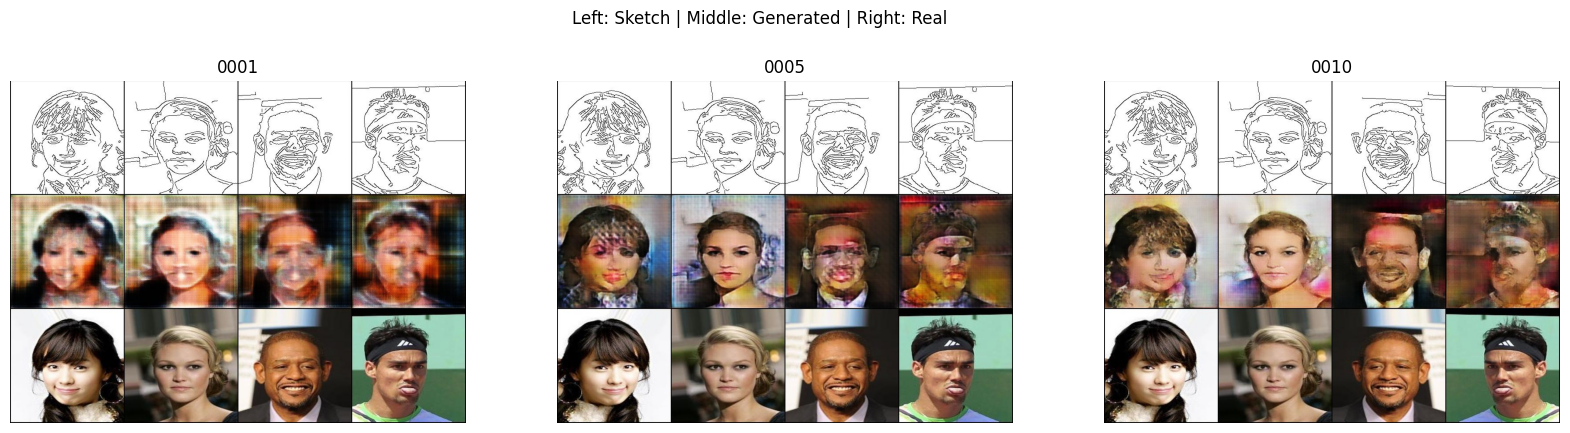

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob

images = sorted(glob.glob("/content/sketch2face/training_progress/*.jpg"))
print(f"Found {len(images)} preview images")

# Show all previews so you can see improvement
fig, axes = plt.subplots(1, len(images), figsize=(20, 5))
for i, img_path in enumerate(images):
    axes[i].imshow(mpimg.imread(img_path))
    axes[i].set_title(img_path.split("_")[-1].replace(".jpg",""))
    axes[i].axis("off")
plt.suptitle("Left: Sketch | Middle: Generated | Right: Real")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/sketch2face/checkpoints",
    "/content/drive/MyDrive/sketch2face_checkpoints",
    dirs_exist_ok=True
)
print("✅ Checkpoints saved to Google Drive!")

KeyboardInterrupt: 

In [ ]:
!mv /content/sketch2face_app.py /content/sketch2face/app.py

In [ ]:
%%writefile /content/sketch2face/app.py
import sys
sys.path.append('/content/sketch2face')

import torch
import gradio as gr
import numpy as np
from PIL import Image
from torchvision import transforms
from models.generator import Generator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator().to(device)
G.load_state_dict(torch.load("/content/sketch2face/checkpoints/generator_final.pth", map_location=device))
G.eval()
print(f"✅ Model loaded on {device}")

def sketch_to_face(sketch):
    if sketch is None:
        return None
    if isinstance(sketch, np.ndarray):
        if sketch.shape[-1] == 4:
            sketch = sketch[:,:,:3]
        sketch = Image.fromarray(sketch.astype(np.uint8))
    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3)
    ])
    with torch.no_grad():
        inp = transform(sketch).unsqueeze(0).to(device)
        out = G(inp).squeeze(0).cpu()
        out = (out*0.5+0.5).clamp(0,1)
    return transforms.ToPILImage()(out)

def upload_to_face(image):
    if image is None:
        return None
    # Convert uploaded image to grayscale sketch style
    if isinstance(image, np.ndarray):
        image = Image.fromarray(image.astype(np.uint8))
    import cv2
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(img_cv, (5,5), 0)
    edges   = cv2.Canny(blurred, 30, 100)
    sketch  = cv2.bitwise_not(edges)
    sketch_rgb = cv2.cvtColor(sketch, cv2.COLOR_GRAY2RGB)
    sketch_pil = Image.fromarray(sketch_rgb)
    return sketch_to_face(sketch_pil)

css = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=DM+Sans:wght@300;400;500&display=swap');
body, .gradio-container { background: #0f0e0c !important; font-family: 'DM Sans', sans-serif !important; }
.app-title { font-family: 'Playfair Display', serif !important; font-size: 2.8rem !important; font-weight: 700 !important; color: #f5f0e8 !important; text-align: center; margin: 0 !important; }
.app-title span { color: #e8572a; }
.subtitle { text-align:center; color:#8c8070; font-size:1rem; margin-top:8px; font-weight:300; }
.divider { width:60px; height:2px; background:#e8572a; margin:16px auto 32px; }
.panel { background:#1a1816 !important; border:1px solid #2a2620 !important; border-radius:16px !important; padding:24px !important; }
.panel-label { font-size:0.7rem; font-weight:500; letter-spacing:3px; text-transform:uppercase; color:#8c8070; margin-bottom:14px; }
.gen-btn { background:#e8572a !important; border:none !important; border-radius:10px !important; color:white !important; font-size:0.85rem !important; font-weight:500 !important; letter-spacing:1px !important; text-transform:uppercase !important; width:100% !important; margin-top:12px !important; transition: all 0.2s !important; }
.gen-btn:hover { background:#d4441f !important; transform:translateY(-1px) !important; box-shadow: 0 8px 24px rgba(232,87,42,0.3) !important; }
.clr-btn { background:transparent !important; border:1px solid #2a2620 !important; border-radius:10px !important; color:#8c8070 !important; font-size:0.8rem !important; width:100% !important; margin-top:8px !important; }
.clr-btn:hover { border-color:#8c8070 !important; color:#f5f0e8 !important; }
.tips { background:#111; border:1px solid #2a2620; border-radius:12px; padding:16px; margin-top:12px; }
.tips-title { font-size:0.7rem; color:#3a342e; text-transform:uppercase; letter-spacing:2px; margin-bottom:10px; }
.tips-list { font-size:0.82rem; color:#5a5248; line-height:2; }
.footer { text-align:center; padding:24px; color:#3a342e; font-size:0.75rem; border-top:1px solid #1a1816; margin-top:24px; }
.footer a { color:#e8572a; text-decoration:none; }
.badge-row { display:flex; justify-content:center; gap:8px; flex-wrap:wrap; margin-top:12px; margin-bottom:32px; }
.badge { background:#1a1816; border:1px solid #2a2620; border-radius:20px; padding:4px 12px; font-size:0.7rem; color:#8c8070; letter-spacing:0.5px; }
.tab-nav button { background:transparent !important; border:none !important; color:#8c8070 !important; font-family:'DM Sans',sans-serif !important; font-size:0.85rem !important; letter-spacing:1px !important; text-transform:uppercase !important; padding:10px 20px !important; border-bottom:2px solid transparent !important; }
.tab-nav button.selected { color:#f5f0e8 !important; border-bottom:2px solid #e8572a !important; }
footer { display:none !important; }
"""

with gr.Blocks(css=css, title="Sketch → Face") as demo:

    gr.HTML("""
        <div style="padding:48px 0 0">
            <h1 class="app-title">Sketch <span>→</span> Face</h1>
            <p class="subtitle">Draw or upload a sketch · AI makes it real</p>
            <div class="divider"></div>
            <div class="badge-row">
                <span class="badge">⚡ Pix2Pix GAN</span>
                <span class="badge">✦ CelebA-HQ</span>
                <span class="badge">🔥 PyTorch</span>
                <span class="badge">by gauravnevarekar</span>
            </div>
        </div>
    """)

    with gr.Row():

        # ── LEFT: Input tabs ──────────────────────────────────────────────────
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="panel-label">✏ Input</div>')

            with gr.Tabs(elem_classes="tab-nav"):

                # Tab 1 — Draw
                with gr.Tab("✏️  Draw Sketch"):
                    sketch_input = gr.Sketchpad(
                        label="",
                        brush=gr.Brush(colors=["#000000"], default_size=3),
                        height=300,
                    )
                    draw_btn   = gr.Button("✦ Generate from Drawing", elem_classes="gen-btn", variant="primary")
                    gr.ClearButton([sketch_input], value="Clear Canvas", elem_classes="clr-btn")

                # Tab 2 — Upload from gallery
                with gr.Tab("🖼️  Upload Sketch"):
                    upload_input = gr.Image(
                        label="",
                        type="numpy",
                        height=300,
                        sources=["upload", "clipboard"],
                    )
                    upload_btn = gr.Button("✦ Generate from Upload", elem_classes="gen-btn", variant="primary")
                    gr.HTML("""
                        <div style="margin-top:10px; padding:12px; background:#111;
                             border-radius:8px; border:1px solid #2a2620;">
                            <div style="font-size:0.7rem; color:#3a342e;
                                 text-transform:uppercase; letter-spacing:2px; margin-bottom:6px;">
                                Supported formats
                            </div>
                            <div style="font-size:0.8rem; color:#5a5248; line-height:1.8;">
                                📁 JPG, PNG, BMP, WEBP<br>
                                📋 Paste from clipboard (Ctrl+V)<br>
                                🖼️ Phone gallery or PC files<br>
                                ✏️ Scanned hand-drawn sketches
                            </div>
                        </div>
                    """)

        # ── RIGHT: Output ─────────────────────────────────────────────────────
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="panel-label">🤖 Generated Face</div>')
            output_img = gr.Image(label="", height=320, show_download_button=True)
            gr.HTML("""
                <div class="tips">
                    <div class="tips-title">Drawing tips for best results</div>
                    <div class="tips-list">
                        ⬭ &nbsp;Oval shape for face outline<br>
                        ◉ &nbsp;Two circles for eyes<br>
                        | &nbsp;&nbsp;Short vertical line for nose<br>
                        ⌣ &nbsp;Curved line for mouth<br>
                        ≋ &nbsp;Lines on top for hair
                    </div>
                </div>
            """)

    # ── Button actions ────────────────────────────────────────────────────────
    draw_btn.click(
        fn=sketch_to_face,
        inputs=[sketch_input],
        outputs=[output_img]
    )
    upload_btn.click(
        fn=upload_to_face,
        inputs=[upload_input],
        outputs=[output_img]
    )

    gr.HTML("""
        <div class="footer">
            Made by <a href="https://github.com/gauravnevarekar">gauravnevarekar</a>
            &nbsp;·&nbsp; Pix2Pix GAN &nbsp;·&nbsp; Trained on CelebA-HQ
        </div>
    """)

demo.launch(share=True, debug=False)

Writing /content/sketch2face/app.py


In [ ]:
%%writefile /content/sketch2face/app.py
import sys
sys.path.append('/content/sketch2face')

import torch
import gradio as gr
import numpy as np
from PIL import Image
from torchvision import transforms
from models.generator import Generator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
G = Generator().to(device)
G.load_state_dict(torch.load("/content/sketch2face/checkpoints/generator_final.pth", map_location=device))
G.eval()
print(f"✅ Model loaded on {device}")

def sketch_to_face(sketch_data):
    if sketch_data is None:
        return None

    # Gradio Sketchpad returns a dict with 'composite', 'background', etc.
    # We need the composite image where the user drew.
    if isinstance(sketch_data, dict):
        sketch = sketch_data.get('composite')
    else:
        sketch = sketch_data

    if isinstance(sketch, np.ndarray):
        if sketch.shape[-1] == 4:
            sketch = sketch[:,:,:3]
        sketch = Image.fromarray(sketch.astype(np.uint8))

    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3)
    ])

    with torch.no_grad():
        inp = transform(sketch).unsqueeze(0).to(device)
        out = G(inp).squeeze(0).cpu()
        out = (out*0.5+0.5).clamp(0,1)
    return transforms.ToPILImage()(out)

css = """
@import url('https://fonts.googleapis.com/css2?family=Playfair+Display:wght@700&family=DM+Sans:wght@300;400;500&display=swap');
body, .gradio-container { background: #0f0e0c !important; font-family: 'DM Sans', sans-serif !important; }
.app-title { font-family: 'Playfair Display', serif !important; font-size: 2.8rem !important; font-weight: 700 !important; color: #f5f0e8 !important; text-align: center; margin: 0 !important; }
.app-title span { color: #e8572a; }
.subtitle { text-align:center; color:#8c8070; font-size:1rem; margin-top:8px; font-weight:300; }
.divider { width:60px; height:2px; background:#e8572a; margin:16px auto 32px; }
.panel { background:#1a1816 !important; border:1px solid #2a2620 !important; border-radius:16px !important; padding:24px !important; }
.panel-label { font-size:0.7rem; font-weight:500; letter-spacing:3px; text-transform:uppercase; color:#8c8070; margin-bottom:14px; }
.gen-btn { background:#e8572a !important; border:none !important; border-radius:10px !important; color:white !important; font-size:0.85rem !important; font-weight:500 !important; letter-spacing:1px !important; text-transform:uppercase !important; width:100% !important; margin-top:12px !important; transition: all 0.2s !important; }
.gen-btn:hover { background:#d4441f !important; transform:translateY(-1px) !important; box-shadow: 0 8px 24px rgba(232,87,42,0.3) !important; }
.clr-btn { background:transparent !important; border:1px solid #2a2620 !important; border-radius:10px !important; color:#8c8070 !important; font-size:0.8rem !important; width:100% !important; margin-top:8px !important; transition: all 0.2s !important; }
.clr-btn:hover { border-color:#8c8070 !important; color:#f5f0e8 !important; }
.tips { background:#111; border:1px solid #2a2620; border-radius:12px; padding:16px; margin-top:12px; }
.tips-title { font-size:0.7rem; color:#3a342e; text-transform:uppercase; letter-spacing:2px; margin-bottom:10px; }
.tips-list { font-size:0.82rem; color:#5a5248; line-height:2; }
.footer { text-align:center; padding:24px; color:#3a342e; font-size:0.75rem; border-top:1px solid #1a1816; margin-top:24px; }
.footer a { color:#e8572a; text-decoration:none; }
.badge-row { display:flex; justify-content:center; gap:8px; flex-wrap:wrap; margin-top:12px; margin-bottom:32px; }
.badge { background:#1a1816; border:1px solid #2a2620; border-radius:20px; padding:4px 12px; font-size:0.7rem; color:#8c8070; letter-spacing:0.5px; }
footer { display:none !important; }
"""

with gr.Blocks(css=css, title="Sketch → Face") as demo:

    gr.HTML("""
        <div style="padding:48px 0 0">
            <h1 class="app-title">Sketch <span>→</span> Face</h1>
            <p class="subtitle">Draw a face · AI makes it real</p>
            <div class="divider"></div>
            <div class="badge-row">
                <span class="badge">⚡ Pix2Pix GAN</span>
                <span class="badge">✦ CelebA-HQ</span>
                <span class="badge">🔥 PyTorch</span>
                <span class="badge">by gauravnevarekar</span>
            </div>
        </div>
    """)

    with gr.Row():
        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="panel-label">✏ Your Sketch</div>')
            sketch_input = gr.Sketchpad(
                label="",
                brush=gr.Brush(colors=["#000000"], default_size=3),
                height=320,
                type="numpy"
            )
            generate_btn = gr.Button("✦ Generate Face", elem_classes="gen-btn", variant="primary")
            clear_btn    = gr.ClearButton([sketch_input], value="Clear Canvas", elem_classes="clr-btn")

        with gr.Column(elem_classes="panel"):
            gr.HTML('<div class="panel-label">🤖 Generated Face</div>')
            output_img = gr.Image(label="", height=320, show_download_button=True)
            gr.HTML("""
                <div class="tips">
                    <div class="tips-title">Drawing tips</div>
                    <div class="tips-list">
                        ⬭ &nbsp;Oval shape for face<br>
                        ◉ &nbsp;Two circles for eyes<br>
                        | &nbsp;&nbsp;Short line for nose<br>
                        ⌣ &nbsp;Curved line for mouth<br>
                        ≋ &nbsp;Lines on top for hair
                    </div>
                </div>
            """)

    generate_btn.click(fn=sketch_to_face, inputs=[sketch_input], outputs=[output_img])

    gr.HTML("""
        <div class="footer">
            Made by <a href="https://github.com/gauravnevarekar">gauravnevarekar</a>
            &nbsp;·&nbsp; Pix2Pix GAN &nbsp;·&nbsp; Trained on CelebA-HQ
        </div>
    """)

demo.launch(share=True, debug=False)

Overwriting /content/sketch2face/app.py


In [ ]:
import os, glob

# Check what checkpoints exist
checkpoints = sorted(glob.glob("/content/sketch2face/checkpoints/*.pth"))
print("Available checkpoints:", checkpoints)

# Use the latest one
if checkpoints:
    latest = checkpoints[-1]
    os.system(f"cp '{latest}' /content/sketch2face/checkpoints/generator_final.pth")
    print(f"✅ Using: {latest}")

Available checkpoints: ['/content/sketch2face/checkpoints/generator_epoch0010.pth', '/content/sketch2face/checkpoints/generator_final.pth']
✅ Using: /content/sketch2face/checkpoints/generator_final.pth


In [ ]:
!pip install -q gradio
%cd /content/sketch2face
!python app.py

/content/sketch2face
✅ Model loaded on cuda
/content/sketch2face/app.py:68: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Sketch → Face") as demo:
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://f8701141fca2e2bb1f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
        

In [ ]:
import os
# Overwrite the app file with the fix and restart
with open('/content/sketch2face/app.py', 'w') as f:
    f.write("""
import sys
sys.path.append('/content/sketch2face')
import torch
import gradio as gr
import numpy as np
from PIL import Image
from torchvision import transforms
from models.generator import Generator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
G = Generator().to(device)
G.load_state_dict(torch.load('/content/sketch2face/checkpoints/generator_final.pth', map_location=device))
G.eval()

def sketch_to_face(sketch_data):
    if sketch_data is None: return None
    # Extract composite image from Gradio dictionary
    if isinstance(sketch_data, dict):
        sketch = sketch_data.get('composite')
    else:
        sketch = sketch_data

    if isinstance(sketch, np.ndarray):
        if sketch.shape[-1] == 4: sketch = sketch[:,:,:3]
        sketch = Image.fromarray(sketch.astype(np.uint8))

    transform = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3,[0.5]*3)
    ])

    with torch.no_grad():
        inp = transform(sketch).unsqueeze(0).to(device)
        out = G(inp).squeeze(0).cpu()
        out = (out*0.5+0.5).clamp(0,1)
    return transforms.ToPILImage()(out)

with gr.Blocks(title='Sketch to Face') as demo:
    gr.Markdown('# Sketch → Face Generator')
    with gr.Row():
        with gr.Column():
            sketch_input = gr.Sketchpad(label='Draw here', type='numpy', layers=False)
            btn = gr.Button('Generate')
        with gr.Column():
            output_img = gr.Image(label='Result')
    btn.click(sketch_to_face, inputs=sketch_input, outputs=output_img)

demo.launch(share=True, inline=True)
""")

print('Re-launching the app...')
!python /content/sketch2face/app.py